## Build a basic chatbot with Langgraph(Graph API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:

class State(TypedDict):
    #TypedDict is a way in Python to specify the structure of a dictionary with types.
    #State is a dictionary-like object with a key "messages" that stores a list of messages.
    #Syntax: Annotated[Type, Metadata]
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]
    

In [3]:

import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:

from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="openai/gpt-oss-120b")

In [5]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10ba8c850>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10bbf4c10>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
llm=init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10bbf7390>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10bbf5c50>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:

## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}
#invoke() is the method that sends input to the model and returns the output.
#Here, it is being passed the entire message history, i.e., state["messages"].
#Effectively, the model sees all previous messages to generate the next response
#The function returns a dictionary with a single key "messages".

In [8]:

graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

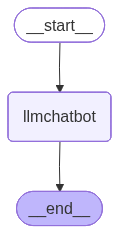

In [9]:

## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:

response=graph.invoke({"messages":"Hi"})

In [11]:

response["messages"][-1].content

'Hello! How can I help you today?'

In [12]:
# for event in graph.stream({"messages":"Hi how are you"}):
#     for value in event.values():
#         print(value)
        
for event in graph.stream({"messages":"Hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm doing great, thanks for asking. How can I help you today?


## Chatbot With Tool

In [13]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
tool.invoke("What is langraph")

{'query': 'What is langraph',
 'response_time': 1.1,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by [LangChain](https://www.ibm.com/think/topics/langchain), is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an [AI agent workflow](https://www.ibm.com/think/topics/ai-agents). The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the [AI workflow](https://www.ibm.com/think/topics/ai-workflow) as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this se

In [14]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [15]:
tools = [tool,multiply]

In [16]:
llm_with_tool = llm.bind_tools(tools)

In [17]:
llm_with_tool

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10bbf7390>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10bbf5c50>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search

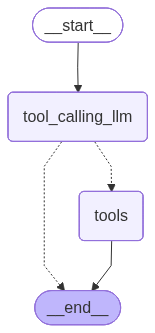

In [21]:

## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
response = graph.invoke({"messages":"what is the recent AI news"})


In [26]:
# response["messages"][-1]
response["messages"][-1].content

'{"query": "latest AI news March 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://news.bloomberglaw.com/daily-labor-report/ex-google-researcher-seeks-to-transform-japans-robots-with-ai", "title": "Ex-Google Researcher Seeks to Transform Japan’s Robots With AI - Bloomberg Law News", "score": 0.98282325, "published_date": "Mon, 09 Mar 2026 04:15:00 GMT", "content": "Daily Labor Report\\n\\nEmail\\n\\nShare To:Facebook\\n\\nLinkedIn\\n\\n# Ex-Google Researcher Seeks to Transform Japan’s Robots With AI\\n\\nMarch 9, 2026, 4:15\u202fAM UTC\\n\\nMin Jeong Lee\\n\\nBloomberg News\\n\\nA Silicon Valley-born AI startup is turning to Japan to prove AI can reshape one of the world’s largest industrial robot supply chains.\\n\\nIntegral AI Inc., a five-year-old company founded by former Google researchers Jad Tarifi and Nima Asgharbeygi, develops AI models geared for automated systems such as robots and self-driving cars. The company has worked with au

In [27]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_4c8bd02d-11c3-4c81-b4c1-d5ec1c8a4e7e)
 Call ID: fc_4c8bd02d-11c3-4c81-b4c1-d5ec1c8a4e7e
  Args:
    query: latest AI news March 2026
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news March 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://news.bloomberglaw.com/daily-labor-report/ex-google-researcher-seeks-to-transform-japans-robots-with-ai", "title": "Ex-Google Researcher Seeks to Transform Japan’s Robots With AI - Bloomberg Law News", "score": 0.98282325, "published_date": "Mon, 09 Mar 2026 04:15:00 GMT", "content": "Daily Labor Report\n\nEmail\n\nShare To:Facebook\n\nLinkedIn\n\n# Ex

In [29]:
response = graph.invoke({"messages":"what is 2 multipled by 3"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 multipled by 3
================================== Ai Message ==================================

2 multiplied by 3 equals **6**.


In [33]:
response = graph.invoke({"messages":"what is 2 multiplied by 3 and then multiply 10 "})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplied by 3 and then multiply 10 
================================== Ai Message ==================================

\(2 \times 3 = 6\)  

\(6 \times 10 = 60\)

So the final result is **60**.


In [34]:
response = graph.invoke({"messages":"Give me the recent ai news and then multiply 2 by 10"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 2 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_5f8f039e-0c5d-4735-a789-d599931328a6)
 Call ID: fc_5f8f039e-0c5d-4735-a789-d599931328a6
  Args:
    query: AI news March 2026
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news March 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.mean.ceo/ai-news-march-2026", "title": "AI News | March, 2026 (STARTUP EDITION)", "content": "Start lean: Most startups will benefit from no-code AI tools (e.g., Canva with AI features).\n   Test, but track: Emphasize experimental frameworks and align AI benefits to measurable KPIs.\n   Rethink your team: AI should play the role of productive co-fo